# Physics-Informed Neural Networks (PINNs) for Groundwater Flow 
## Learning Objectives

By the end of this notebook, you will be able to:

- Understand the governing equation of groundwater flow.
- Explain the basic concept of Physics-Informed Neural Networks (PINNs).
- Build a neural network using PyTorch.
- Compute derivatives using automatic differentiation.
- Construct a physics-based loss function.
- Train a PINN to solve a groundwater flow problem.
- Visualize and interpret hydraulic head predictions.


## 1. Introduction

Traditional numerical methods such as:

- Finite Difference Method (FDM)
- Finite Element Method (FEM)
- Meshfree Methods

solve differential equations by discretizing the governing equations.

Physics-Informed Neural Networks (PINNs) solve differential equations differently.

Instead of solving for values at grid points, a neural network is trained to approximate the solution while satisfying:

- Governing equations
- Boundary conditions
- Initial conditions


## 2. Problem Definition

### Governing Equation

Consider steady one-dimensional groundwater flow:

$$
T \frac{d^2 h}{dx^2} + Q = 0
$$

where:

| Symbol | Description |
|----------|-------------|
| $h$ | Hydraulic head |
| $T$ | Transmissivity |
| $Q$ | Recharge term |

### Domain

$$
0 \leq x \leq 10
$$

### Boundary Conditions

$$
h(0) = 10
$$

$$
h(10) = 5
$$

## 3. PINN Concept

Instead of solving directly for $h$, we train a neural network:

$$
h = \mathrm{NN}(x)
$$

The network receives:

**Input:**

$$
x
$$

**Output:**

$$
h(x)
$$

### Goal

Train the network so that its output satisfies the governing equation

$$
T \frac{d^2 h}{dx^2} + Q = 0
$$

everywhere in the domain.

## 4. Import Required Libraries

In [18]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## 5. Building a Neural Network

A neural network is simply a mathematical function.

In this example:

x→20→20→h
### Code

In [19]:
class PINN(nn.Module):

    def __init__(self):

        super(PINN,self).__init__()

        self.net = nn.Sequential(

            nn.Linear(1,20),
            nn.Tanh(),

            nn.Linear(20,20),
            nn.Tanh(),

            nn.Linear(20,1)

        )

    def forward(self,x):

        return self.net(x)

## Discussion
Why do we use Tanh?
- Smooth function
- Differentiable everywhere
- Good for PDE problems

## 6. Create the Model

In [20]:
model = PINN()

The model currently contains random weights.

Therefore predictions are meaningless.

## 7. Understanding Automatic Differentiation

One powerful feature of PyTorch is Automatic Differentiation.

Suppose

$$y=x^2 $$

Then

$$ dx/dy =2x $$

PyTorch can compute derivatives automatically.

Example:

In [21]:
x = torch.tensor([2.0], requires_grad=True)

y = x**2

dy_dx = torch.autograd.grad(
    y,
    x,
    create_graph=True
)[0]

print(dy_dx)

tensor([4.], grad_fn=<MulBackward0>)


## 8. Why Automatic Differentiation is Important

Our governing equation contains the second derivative of hydraulic head:

$$
\frac{d^2 h}{dx^2}
$$

Therefore, we need to compute:

### First Derivative

$$
\frac{dh}{dx}
$$

### Second Derivative

$$
\frac{d^2 h}{dx^2}
$$

These derivatives are computed directly from the neural network using **automatic differentiation**, a key feature of PyTorch.

## 9. Constructing the Physics Loss

The governing equation is

$$
T \frac{d^2 h}{dx^2} + Q = 0
$$

We define the PDE residual as

$$
R(x) = T \frac{d^2 h}{dx^2} + Q
$$

For a perfect solution,

$$
R(x) = 0
$$

at every point in the domain.

The physics loss is defined as the mean squared residual:

$$
\mathcal{L}_{\text{physics}}
=
\frac{1}{N}
\sum_{i=1}^{N}
R(x_i)^2
$$

Minimizing this loss forces the neural network to satisfy the groundwater flow equation throughout the domain.

### Code:

In [22]:
def physics_loss(model,x,T=1.0,Q=0.5):

    x.requires_grad_(True)

    h = model(x)

    dh_dx = torch.autograd.grad(
        h,
        x,
        torch.ones_like(h),
        create_graph=True
    )[0]

    dh_dx2 = torch.autograd.grad(
        dh_dx,
        x,
        torch.ones_like(dh_dx),
        create_graph=True
    )[0]

    residual = T*dh_dx2 + Q

    return torch.mean(residual**2)

## 10. Collocation Points

PINNs enforce physics at selected points inside the domain.

These points are called:

### Collocation Points

In [23]:
x_domain = torch.linspace(0,10,100).view(-1,1)

Visual representation:

## 11. Boundary Conditions

Boundary conditions anchor the solution.

Given:

$$ h(0)=10$$
$$ h(10)=5 $$

Code:

In [24]:
bc_x = torch.tensor([[0.0],[10.0]])

bc_h = torch.tensor([[10.0],[5.0]])

## 12. Boundary Loss

The network must satisfy:

$$ h_{pred}=h_{known}$$



Loss:

$$ MSE=(h_{pred}−h_{known})^2 $$

Code

In [25]:
h_pred_bc = model(bc_x)

loss_bc = torch.mean(
    (h_pred_bc-bc_h)**2
)

## 13. Total Loss Function

Two objectives:

Physics
$$L_{PDE}$$
	​

Boundary Conditions
$$ L_{BC} $$
	​


Total:

$$ L=L_{PDE} +L_{BC} $$
	​
## 14. Optimizer

Optimizer updates network weights.

We use Adam.

In [26]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

## 15. Training Loop

In [31]:
# 4. Training Loop
for epoch in range(2000):
    optimizer.zero_grad()
    
    # Boundary Loss
    h_pred_bc = model(bc_x)
    loss_bc = torch.mean((h_pred_bc - bc_h)**2)
    
    # Physics Loss
    loss_pde = physics_loss(model, x_domain)
    
    # Total Loss
    total_loss = loss_bc + loss_pde
    total_loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {total_loss.item():.6f}")

Epoch 0: Loss 57.881687
Epoch 500: Loss 0.114022
Epoch 1000: Loss 0.051011
Epoch 1500: Loss 0.008785


## 18. Making Predictions

In [32]:
x_test = torch.linspace(
    0,
    10,
    100
).view(-1,1)

model.eval()

with torch.no_grad():

    h_pred = model(x_test)

## 19. Post-Processing

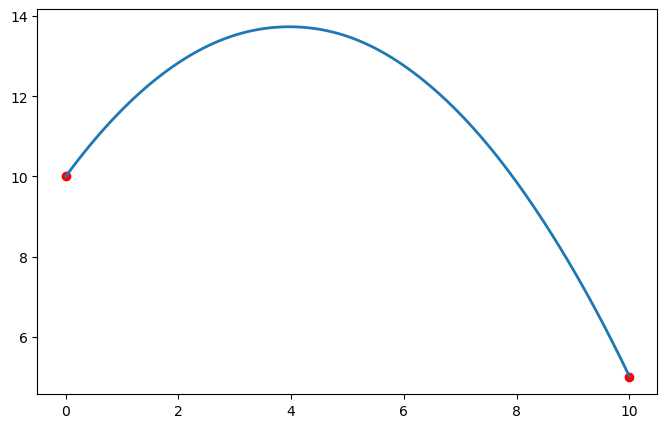

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    x_test.numpy(),
    h_pred.numpy(),
    linewidth=2
)

plt.scatter(
    bc_x.numpy(),
    bc_h.numpy(),
    color='red'
)

## Key Takeaways

A PINN consists of:

1. Neural Network
$$ x→h(x) $$
2. Physics Residual
$$ Th
xx
+Q $$
3. Boundary Conditions
$$ h(0)=10,h(10)=5 $$ 
4. Loss Function
$$ L=L
_{PDE}
+L
_{BC}$$

5. Optimization

using gradient descent.

This simple example forms the foundation for more advanced PINNs used in:

- Groundwater flow
- Richards equation
- Solute transport
- Heat transfer
- Multiphysics systems.